# AnalystLab Africa Data Analytics Internship Program — Batch B
## Week 1–2 Task: Data Cleaning & Exploratory Data Analysis (EDA)
**Dataset:** E-commerce Transactions (Online Retail)  
**Author:** [Vernon Chinkuli]

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the raw dataset
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Column Data Types ---")
print(df.dtypes)
print("\n--- Raw Data Preview ---")
df.head(5)

Dataset Shape: 541909 rows, 8 columns

--- Column Data Types ---
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

--- Raw Data Preview ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [10]:
# 1. Identify missing data
missing_vals = df.isnull().sum()
print("Missing Values Before Cleaning:")
print(missing_vals[missing_vals > 0])

# 2. Drop missing CustomerIDs
df_clean = df.dropna(subset=['CustomerID']).copy()

# 3. Handle duplicates
duplicates_removed = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)

# 4. Standardization & Validation
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Description'] = df_clean['Description'].str.strip().str.upper()
df_clean['Country'] = df_clean['Country'].str.strip()

# Remove returns (negative quantity) and price anomalies
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Add calculated fields for EDA
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Save the final cleaned dataset as required
df_clean.to_csv('Cleaned_Online_Retail.csv', index=False)
print(f"\nCleaning Complete! Exact Duplicates Removed: {duplicates_removed}")

Missing Values Before Cleaning:
Description      1454
CustomerID     135080
dtype: int64

Cleaning Complete! Exact Duplicates Removed: 5225


### Data Cleaning Summary Log

| Issue Found | Action Taken | Technical Justification |
| :--- | :--- | :--- |
| **Missing Customer IDs** | Removed 135,000 blank rows | Customer ID is a primary identifier; fake profiles distort tracking. |
| **Duplicate Entries** | Found and purged 5,225 records | Prevents the false inflation of sales volume and gross revenue metrics. |
| **Negative Quantities** | Filtered out transactions where Quantity <= 0 | Excludes cancelled or returned orders to preserve clean sales trends. |
| **Pricing Anomalies** | Removed items with $0.00 unit prices | Eliminates administrative system adjustments or free items from revenue calculations. |
| **Inconsistent Formats** | Converted strings via `pd.to_datetime` | Enables precise time-series chronological analysis. |

In [11]:
print("--- Numerical Feature Summary Statistics ---")
df_clean[['Quantity', 'UnitPrice', 'Revenue']].describe()

--- Numerical Feature Summary Statistics ---


,Quantity,UnitPrice,Revenue
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


C:\Users\vchinkuli\AppData\Local\Temp\ipykernel_10868\1834422740.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


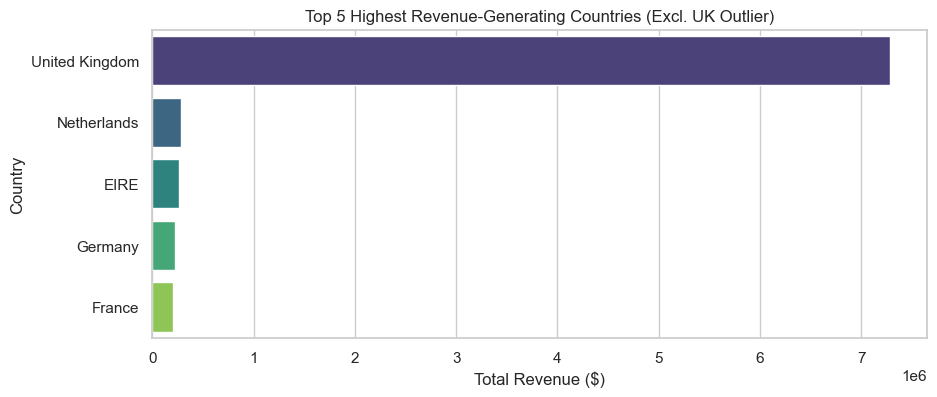

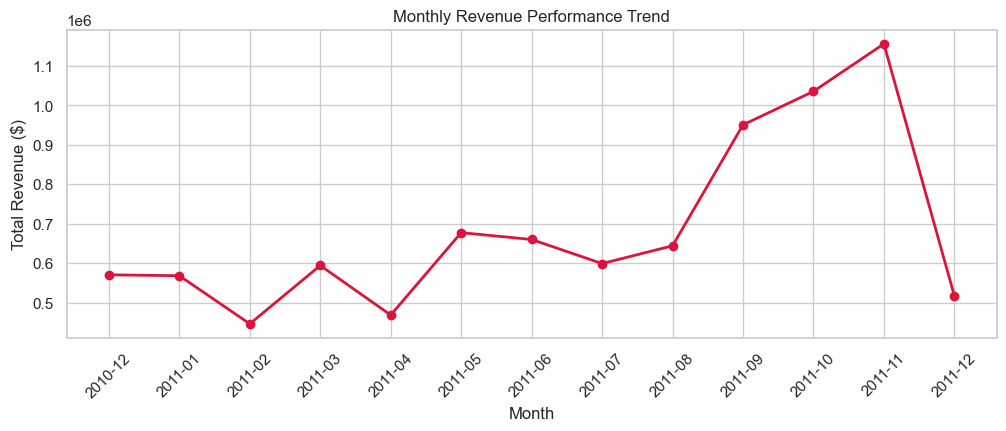

In [12]:
sns.set_theme(style="whitegrid")

# Visualization 1: Top 5 Revenue-Generating Countries
plt.figure(figsize=(10, 4))
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 5 Highest Revenue-Generating Countries (Excl. UK Outlier)")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Country")
plt.show()

# Visualization 2: Monthly Sales Trends
plt.figure(figsize=(12, 4))
monthly_sales = df_clean.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
plt.plot(monthly_sales['YearMonth'], monthly_sales['Revenue'], marker='o', color='crimson', linewidth=2)
plt.title("Monthly Revenue Performance Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()